# 13. Fundamentals of Transformers
---

The Transformer architecture, introduced in the 2017 paper *"Attention Is All You Need"*, is the most important architectural development in the history of deep learning. It powers GPT-4, Claude, Gemini, BERT, and virtually every state-of-the-art model in language, vision, protein folding, and beyond.

This notebook builds a Transformer from scratch, explaining every component and why it exists.

## 13.1 Why Not RNNs? What Transformers Replaced

Before 2017, sequences (text, audio, time series) were handled by **Recurrent Neural Networks (RNNs)**. An RNN processes one token at a time, left to right, passing a hidden state forward:

```
"The  cat  sat  on  the  mat"
  │    │    │    │    │    │
 [RNN]→[RNN]→[RNN]→[RNN]→[RNN]→[RNN]
  h₁   h₂   h₃   h₄   h₅   h₆
```

The hidden state `h` is supposed to carry all relevant information from previous tokens forward. This creates two fundamental problems:

**Problem 1: Sequential bottleneck.** Each step depends on the previous one — you cannot compute `h₃` until you have `h₂`. This means RNNs cannot be parallelised across the sequence dimension. Training on modern hardware (GPUs that are built for parallel computation) is very slow.

**Problem 2: Memory fades.** The hidden state is a single fixed-size vector (say, 512 numbers). By the time you reach token 500 in a long document, the information from token 1 has been compressed, overwritten, and partially lost. Even LSTMs (the most advanced RNN variant) struggle with dependencies longer than ~100 tokens.

**The Transformer solution:** Process the entire sequence at once, and let every token directly attend to every other token — no bottleneck, no fading memory, fully parallelisable.

Libraries loaded


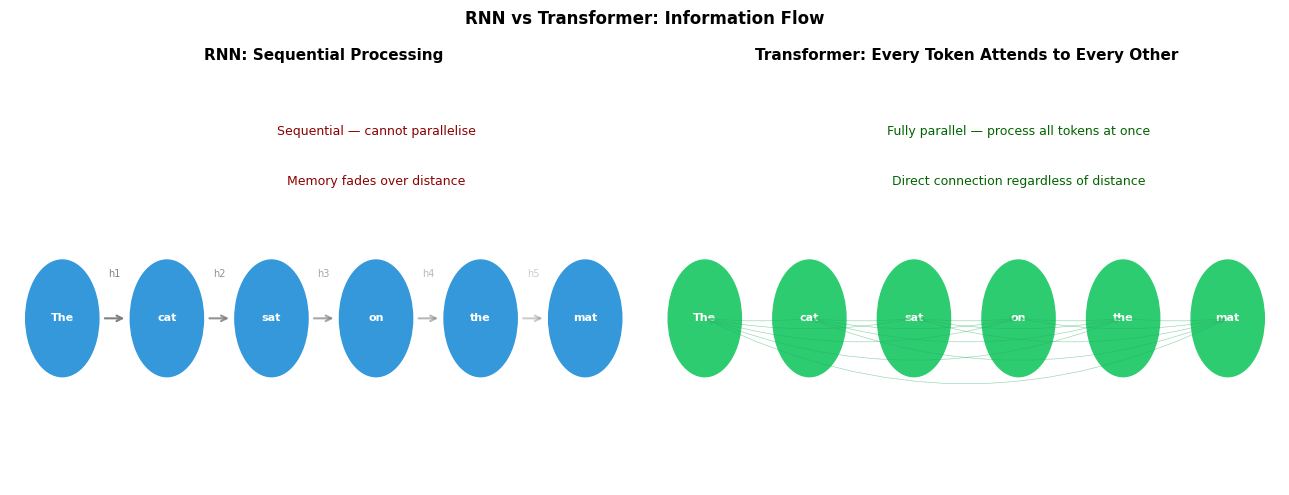

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

torch.manual_seed(42)
print("Libraries loaded")

# Visualise the key difference between RNN and Transformer information flow
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tokens  = ['The', 'cat', 'sat', 'on', 'the', 'mat']
n       = len(tokens)

# --- RNN: sequential, fading memory ---
ax = axes[0]
ax.set_xlim(-0.5, n-0.5); ax.set_ylim(-0.5, 2)
for i, tok in enumerate(tokens):
    ax.add_patch(plt.Circle((i, 0.5), 0.35, color='#3498DB', zorder=3))
    ax.text(i, 0.5, tok, ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if i < n-1:
        alpha = max(0.1, 1 - i*0.15)  # arrow fades = memory fades
        ax.annotate('', xy=(i+1-0.38, 0.5), xytext=(i+0.38, 0.5),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, alpha=alpha))
        ax.text(i+0.5, 0.75, f'h{i+1}', fontsize=7, ha='center', color='gray', alpha=alpha)

ax.text(n//2, 1.6, 'Sequential — cannot parallelise', ha='center', fontsize=9, color='darkred')
ax.text(n//2, 1.3, 'Memory fades over distance', ha='center', fontsize=9, color='darkred')
ax.set_title('RNN: Sequential Processing', fontweight='bold', fontsize=11)
ax.axis('off')

# --- Transformer: every token attends to every other ---
ax = axes[1]
ax.set_xlim(-0.5, n-0.5); ax.set_ylim(-0.5, 2)
for i, tok in enumerate(tokens):
    ax.add_patch(plt.Circle((i, 0.5), 0.35, color='#2ECC71', zorder=3))
    ax.text(i, 0.5, tok, ha='center', va='center', fontsize=8, color='white', fontweight='bold')

for i in range(n):
    for j in range(n):
        if i != j:
            ax.annotate('', xy=(j, 0.5), xytext=(i, 0.5),
                        arrowprops=dict(arrowstyle='->', color='#27AE60', lw=0.4, alpha=0.3,
                                        connectionstyle=f'arc3,rad={0.3*(j-i)/n}'))

ax.text(n//2, 1.6, 'Fully parallel — process all tokens at once', ha='center', fontsize=9, color='darkgreen')
ax.text(n//2, 1.3, 'Direct connection regardless of distance', ha='center', fontsize=9, color='darkgreen')
ax.set_title('Transformer: Every Token Attends to Every Other', fontweight='bold', fontsize=11)
ax.axis('off')

plt.suptitle('RNN vs Transformer: Information Flow', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 13.2 Self-Attention: The Core Idea

**Attention** is the mechanism that lets each token look at every other token and decide how much to "attend" to each one.

Consider: *"The cat sat on the mat because **it** was tired."*

When processing the word **"it"**, the model should attend strongly to **"cat"** to resolve the pronoun. Traditional models had to carry this information through many steps. Attention makes it a direct, learned connection.

### Query, Key, Value — the Library Analogy

Every token is projected into three vectors:

- **Query (Q):** "What information am I looking for?" — like a search query
- **Key (K):** "What information do I contain?" — like a document title
- **Value (V):** "What am I actually contributing?" — like the document content

The process: each token sends its **Query** to every other token's **Key**. The dot product measures how well they match. Softmax converts matches into probabilities (attention weights). The output is a weighted sum of all **Values**.

```
                Q("it") · K("cat")   = HIGH  → attend 60%
"it" asks: →   Q("it") · K("mat")   = LOW   → attend 5%
                Q("it") · K("sat")   = MED   → attend 20%
                ...
                ↓ softmax → ↓ multiply by V and sum
                Output = 0.60 × V("cat") + 0.05 × V("mat") + 0.20 × V("sat") + ...
```

The formula:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The $\sqrt{d_k}$ scaling prevents the dot products from getting too large when the dimension is high (large values push softmax into regions where gradients vanish).

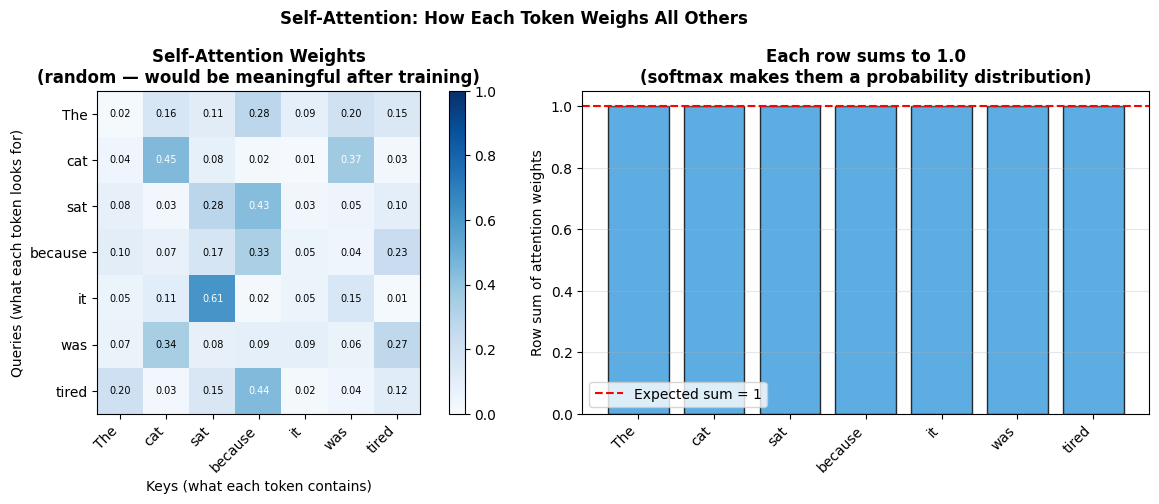

Output shape: torch.Size([1, 7, 16])  — same shape as input, just re-weighted by context


In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k          = Q.shape[-1]
    scores       = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    if mask is not None:
        scores   = scores.masked_fill(mask == 0, float('-inf'))
    attn_weights = F.softmax(scores, dim=-1)
    return attn_weights @ V, attn_weights

# Visualise attention weights for a toy sentence
tokens   = ['The', 'cat', 'sat', 'because', 'it', 'was', 'tired']
seq_len  = len(tokens)
d_k      = 16

Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

output, attn = scaled_dot_product_attention(Q, K, V)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Attention heatmap
im = axes[0].imshow(attn[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(seq_len)); axes[0].set_yticks(range(seq_len))
axes[0].set_xticklabels(tokens, rotation=45, ha='right')
axes[0].set_yticklabels(tokens)
axes[0].set_xlabel('Keys (what each token contains)')
axes[0].set_ylabel('Queries (what each token looks for)')
axes[0].set_title('Self-Attention Weights\n(random — would be meaningful after training)', fontweight='bold')
plt.colorbar(im, ax=axes[0])
for i in range(seq_len):
    for j in range(seq_len):
        v = attn[0,i,j].item()
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=7, color='white' if v > 0.35 else 'black')

# Each row sums to 1
row_sums = attn[0].sum(dim=1).detach().numpy()
axes[1].bar(range(seq_len), row_sums, color='#3498DB', alpha=0.8, edgecolor='k')
axes[1].axhline(1.0, color='red', linestyle='--', label='Expected sum = 1')
axes[1].set_xticks(range(seq_len)); axes[1].set_xticklabels(tokens, rotation=45, ha='right')
axes[1].set_ylabel('Row sum of attention weights')
axes[1].set_title('Each row sums to 1.0\n(softmax makes them a probability distribution)', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Self-Attention: How Each Token Weighs All Others', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Output shape: {output.shape}  — same shape as input, just re-weighted by context")

## 13.3 Multi-Head Attention

One set of Q, K, V projections gives one "view" of the sequence. But a sentence contains many different types of relationships simultaneously:
- Syntactic: which word is the subject, which is the verb?
- Coreference: which pronoun refers to which noun?
- Semantic: which words are similar in meaning?

**Multi-Head Attention** runs h attention computations in parallel, each with its own Q, K, V projection matrices. Each head can specialise in a different type of relationship. The results are concatenated and projected back to the model dimension.

```
           Input X (seq_len × d_model)
               │
    ┌──────────┼──────────┐
    │          │          │
  Head 1    Head 2    Head 3  ...
(Q₁K₁V₁) (Q₂K₂V₂) (Q₃K₃V₃)
  Syntactic  Coref  Semantic
    │          │          │
    └──────────┼──────────┘
          Concatenate
               │
          Linear (Wₒ)
               │
           Output
```

If `d_model=64` and `n_heads=8`, each head works with `d_k = 64/8 = 8` dimensions. The total computation is the same as one head, but the heads can specialise independently.

Input:             (2, 10, 64)      (batch, seq_len, d_model)
Output:            (2, 10, 64)      ← same shape as input
Attention weights: (2, 8, 10, 10)  ← (batch, n_heads, seq, seq)
Params in MHA:     16,640


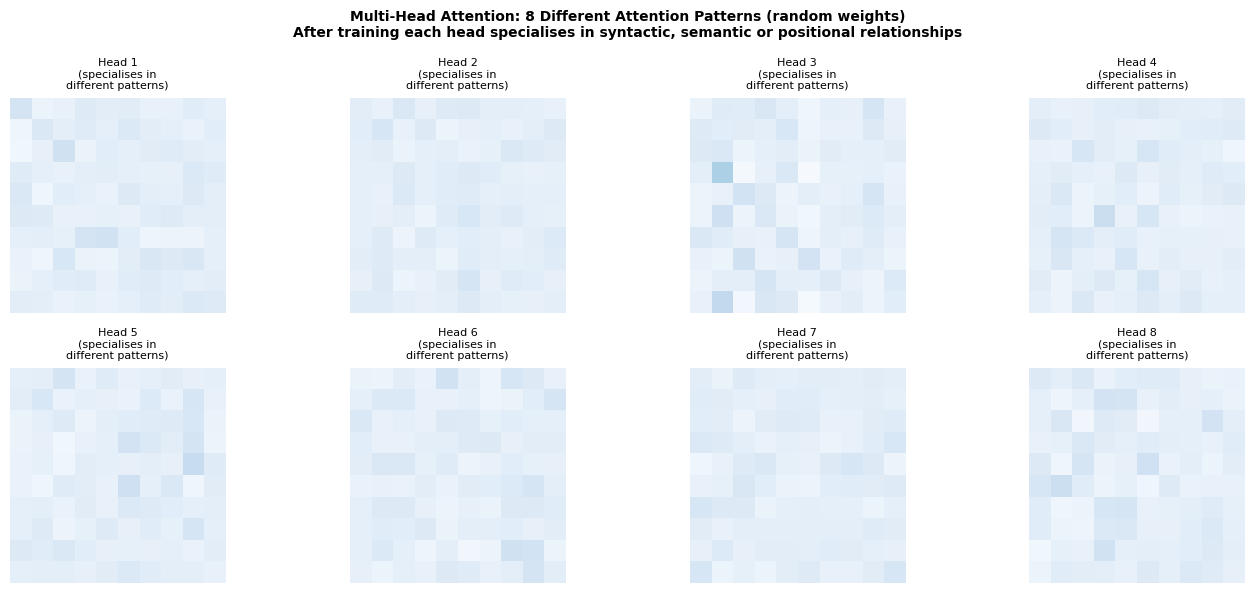

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_k     = d_model // n_heads
        self.n_heads = n_heads
        self.W_q     = nn.Linear(d_model, d_model)
        self.W_k     = nn.Linear(d_model, d_model)
        self.W_v     = nn.Linear(d_model, d_model)
        self.W_o     = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        B, S, _ = x.shape
        return x.view(B, S, self.n_heads, self.d_k).transpose(1, 2)  # (B, h, S, d_k)

    def forward(self, x):
        B, S, _ = x.shape
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        out, attn = scaled_dot_product_attention(Q, K, V)
        out = out.transpose(1, 2).contiguous().view(B, S, -1)  # re-concatenate heads
        return self.W_o(out), attn

d_model, n_heads, seq_len = 64, 8, 10
mha = MultiHeadAttention(d_model, n_heads)
x   = torch.randn(2, seq_len, d_model)
out, attn_weights = mha(x)

print(f"Input:             {tuple(x.shape)}      (batch, seq_len, d_model)")
print(f"Output:            {tuple(out.shape)}      ← same shape as input")
print(f"Attention weights: {tuple(attn_weights.shape)}  ← (batch, n_heads, seq, seq)")
print(f"Params in MHA:     {sum(p.numel() for p in mha.parameters()):,}")

# Visualise one batch, all 8 heads
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for h, ax in enumerate(axes.flat):
    ax.imshow(attn_weights[0, h].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'Head {h+1}\n(specialises in\ndifferent patterns)', fontsize=8)
    ax.axis('off')
plt.suptitle('Multi-Head Attention: 8 Different Attention Patterns (random weights)\nAfter training each head specialises in syntactic, semantic or positional relationships',
             fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

## 13.4 Positional Encoding

Attention has no built-in concept of order. The sentence "dog bites man" and "man bites dog" would produce identical attention patterns if the word vectors were the same — because attention treats the sequence as a **set**, not a sequence.

We fix this by adding a **positional encoding** to each token's embedding — a unique signal that tells the model where each token sits in the sequence.

The original Transformer uses sinusoidal functions:
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \quad PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Each position gets a unique fingerprint of sine and cosine waves at different frequencies — low frequencies change slowly across positions, high frequencies change rapidly. The model learns to decode these patterns.

Why sinusoids? They have a useful property: the encoding for position `pos + k` can be expressed as a linear function of the encoding for position `pos` — this lets the model generalise to sequence lengths not seen during training.

Modern models often use **rotary position embeddings (RoPE)** or **learned** position embeddings instead, but the concept is the same: inject position information additively into the token representations.

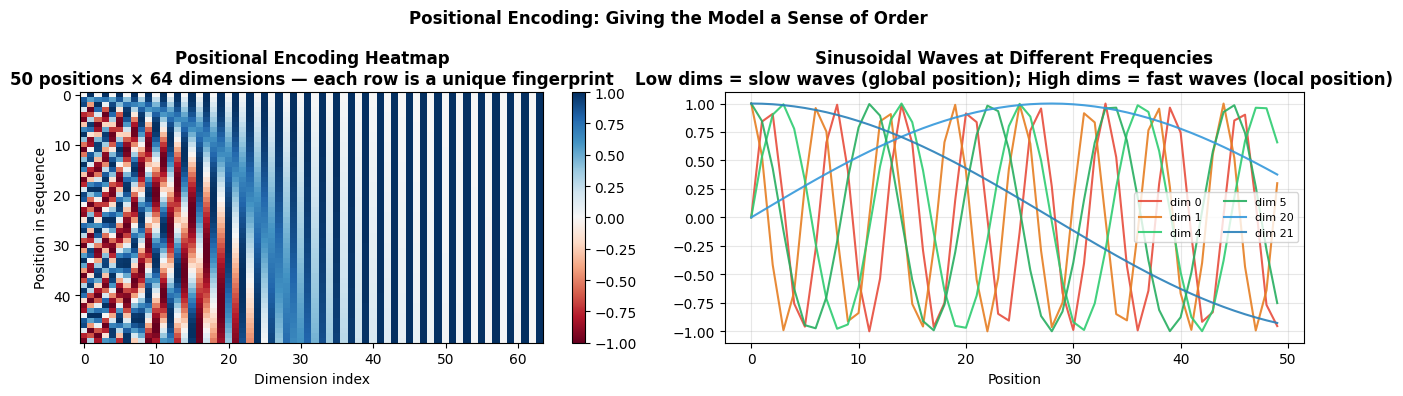

Position 0 encoding (first 8 dims):  [0. 1. 0. 1. 0. 1. 0. 1.]
Position 1 encoding (first 8 dims):  [0.841 0.54  0.682 0.732 0.533 0.846 0.409 0.912]
Position 49 encoding (first 8 dims): [-0.954  0.301 -0.816  0.578  0.659 -0.752  0.971 -0.24 ]

Every position has a unique pattern — the model can decode sequence order from this.


In [4]:
def positional_encoding(seq_len, d_model):
    PE  = torch.zeros(seq_len, d_model)
    pos = torch.arange(0, seq_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    PE[:, 0::2] = torch.sin(pos * div)
    PE[:, 1::2] = torch.cos(pos * div)
    return PE

PE = positional_encoding(seq_len=50, d_model=64)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = axes[0].imshow(PE.numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xlabel('Dimension index'); axes[0].set_ylabel('Position in sequence')
axes[0].set_title('Positional Encoding Heatmap\n50 positions × 64 dimensions — each row is a unique fingerprint',
                  fontweight='bold')
plt.colorbar(im, ax=axes[0])

for dim, col in zip([0, 1, 4, 5, 20, 21], ['#E74C3C','#E67E22','#2ECC71','#27AE60','#3498DB','#2980B9']):
    axes[1].plot(PE[:, dim].numpy(), label=f'dim {dim}', color=col, alpha=0.9, lw=1.5)
axes[1].set_title('Sinusoidal Waves at Different Frequencies\nLow dims = slow waves (global position); High dims = fast waves (local position)',
                  fontweight='bold')
axes[1].set_xlabel('Position'); axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.suptitle('Positional Encoding: Giving the Model a Sense of Order', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Show how position changes the token representation
print("Position 0 encoding (first 8 dims): ", PE[0, :8].numpy().round(3))
print("Position 1 encoding (first 8 dims): ", PE[1, :8].numpy().round(3))
print("Position 49 encoding (first 8 dims):", PE[49, :8].numpy().round(3))
print("\nEvery position has a unique pattern — the model can decode sequence order from this.")

## 13.5 The Transformer Encoder Block

One encoder block combines all the pieces we have built:

```
       Input X
          │
          ├──────────────────────────┐  ← Residual (skip connection)
          ▼                          │
      LayerNorm                      │
          ▼                          │
  Multi-Head Attention               │
          ▼                          │
        Dropout                      │
          ▼                          │
          └──────────────────────────┘
          │  (Add: x = x + attention_output)
          ├──────────────────────────┐  ← Second residual
          ▼                          │
      LayerNorm                      │
          ▼                          │
    Feed-Forward Network             │
    (Linear → ReLU → Linear)         │
          ▼                          │
        Dropout                      │
          ▼                          │
          └──────────────────────────┘
          │  (Add: x = x + ff_output)
          ▼
       Output  (same shape as Input)
```

### Residual connections
The `x = x + sublayer(x)` pattern creates a **direct gradient highway** from the output all the way back to the input. Without this, gradients would have to flow through every layer and would vanish in deep networks (the same problem we saw with sigmoid in Notebook 9). GPT-3 has 96 encoder blocks stacked on top of each other — residual connections are what makes this trainable.

### LayerNorm vs BatchNorm
Recall BatchNorm from Notebook 9 normalises across the batch dimension. For sequences this is problematic — sentences have different lengths, and the batch statistics change with context. **LayerNorm** normalises across the feature dimension within each individual token, making it independent of batch size and sequence length. This is the standard normalisation in all Transformer models.

In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model)
        )
    def forward(self, x): return self.net(x)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, n_heads)
        self.ff    = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(self.norm1(x))
        x = x + self.drop(attn_out)           # residual 1
        x = x + self.drop(self.ff(self.norm2(x)))  # residual 2
        return x

block = TransformerEncoderBlock(d_model=64, n_heads=8, d_ff=256)
x     = torch.randn(2, 10, 64)
out   = block(x)

print(f"Encoder block input:  {tuple(x.shape)}")
print(f"Encoder block output: {tuple(out.shape)}  ← same shape — blocks are stackable")
print(f"Parameters per block: {sum(p.numel() for p in block.parameters()):,}")

# Show the value of residual connections
print("\n--- Why residual connections matter ---")
print("Gradient norm without residual (simulated):")
grad_no_res = 1.0
for i in range(12):
    grad_no_res *= 0.8  # typical gradient shrinkage per layer
    if i % 3 == 2:
        print(f"  Layer {i+1}: {grad_no_res:.6f}")

print("Gradient norm with residual (stays close to 1.0 — gradient highway):")
grad_res = 1.0
for i in range(12):
    grad_res = grad_res + 0.8 * grad_res * 0.1  # residual keeps gradient alive
    if i % 3 == 2:
        print(f"  Layer {i+1}: {grad_res:.4f}")

Encoder block input:  (2, 10, 64)
Encoder block output: (2, 10, 64)  ← same shape — blocks are stackable
Parameters per block: 49,984

--- Why residual connections matter ---
Gradient norm without residual (simulated):
  Layer 3: 0.512000
  Layer 6: 0.262144
  Layer 9: 0.134218
  Layer 12: 0.068719
Gradient norm with residual (stays close to 1.0 — gradient highway):
  Layer 3: 1.2597
  Layer 6: 1.5869
  Layer 9: 1.9990
  Layer 12: 2.5182


## 13.6 Causal Masking — GPT vs BERT

There are two fundamentally different ways to use the Transformer architecture, distinguished by how attention is masked:

**BERT-style (encoder, bidirectional):** Every token attends to every other token — past and future. The model sees the full context in both directions. Used for understanding tasks: classification, named entity recognition, question answering.

**GPT-style (decoder, causal):** Each token can only attend to itself and previous tokens — never future ones. This is essential for text generation: the model must generate the next token without having seen it yet. Also called an **autoregressive** model — it generates one token at a time, left to right.

```
BERT (bidirectional)         GPT (causal/autoregressive)

Pos:  1  2  3  4             Pos:  1  2  3  4
  1 [ ✓  ✓  ✓  ✓ ]            1 [ ✓  ✗  ✗  ✗ ]
  2 [ ✓  ✓  ✓  ✓ ]            2 [ ✓  ✓  ✗  ✗ ]
  3 [ ✓  ✓  ✓  ✓ ]            3 [ ✓  ✓  ✓  ✗ ]
  4 [ ✓  ✓  ✓  ✓ ]            4 [ ✓  ✓  ✓  ✓ ]

  All tokens see all           Token 3 can't see token 4
  (good for understanding)     (good for generation)
```

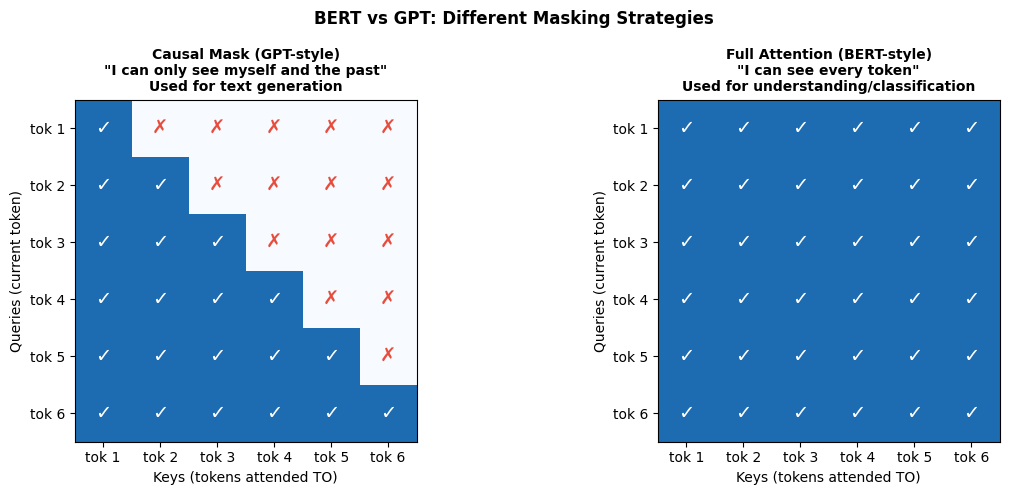

In [6]:
seq_len = 6
causal_mask = torch.tril(torch.ones(seq_len, seq_len)).bool()
full_mask   = torch.ones(seq_len, seq_len).bool()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = [
    'Causal Mask (GPT-style)\n"I can only see myself and the past"\nUsed for text generation',
    'Full Attention (BERT-style)\n"I can see every token"\nUsed for understanding/classification'
]
masks   = [causal_mask, full_mask]
tok_ids = [f'tok {i+1}' for i in range(seq_len)]

for ax, mask, title in zip(axes, masks, titles):
    ax.imshow(mask.numpy().astype(float), cmap='Blues', vmin=0, vmax=1.3)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks(range(seq_len)); ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tok_ids); ax.set_yticklabels(tok_ids)
    ax.set_xlabel('Keys (tokens attended TO)'); ax.set_ylabel('Queries (current token)')
    for i in range(seq_len):
        for j in range(seq_len):
            symbol = '✓' if mask[i,j] else '✗'
            color  = 'white' if mask[i,j] else '#E74C3C'
            ax.text(j, i, symbol, ha='center', va='center', fontsize=14, color=color)

plt.suptitle('BERT vs GPT: Different Masking Strategies', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 13.7 Putting It Together — A Mini Transformer

The full encoder architecture:

```
Input token IDs
       │
  Embedding table  (vocab_size × d_model)
       +
  Positional encoding
       │
  ┌─────────────────────────────────┐
  │  TransformerEncoderBlock        │  ×  N layers
  │  (Attention + FF + Residuals)   │
  └─────────────────────────────────┘
       │
  LayerNorm
       │
  Mean pool over sequence
       │
  Linear classifier
       │
   Output logits
```

In [7]:
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, n_classes, max_len=50):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.register_buffer('pe', positional_encoding(max_len, d_model))
        self.layers     = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        self.norm       = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        S   = x.shape[1]
        emb = self.embedding(x) + self.pe[:S]
        for layer in self.layers:
            emb = layer(emb)
        return self.classifier(self.norm(emb).mean(dim=1))

configs = [
    dict(vocab_size=1000, d_model=64,  n_heads=4, d_ff=256,  n_layers=2,  n_classes=3, label='Small (2L)'),
    dict(vocab_size=1000, d_model=128, n_heads=8, d_ff=512,  n_layers=6,  n_classes=3, label='Medium (6L)'),
    dict(vocab_size=1000, d_model=256, n_heads=8, d_ff=1024, n_layers=12, n_classes=3, label='Large (12L)'),
]

x_dummy = torch.randint(0, 1000, (8, 20))

print(f"{'Config':<15} {'Params':>12} {'Relative to Small':>20}")
print("-"*50)
small_params = None
for cfg in configs:
    label = cfg.pop('label')
    m     = MiniTransformer(**cfg)
    p     = sum(par.numel() for par in m.parameters())
    if small_params is None: small_params = p
    print(f"{label:<15} {p:>12,} {p/small_params:>19.1f}×")

print("\nFor reference:")
print("  GPT-2 (124M params)  ≈ 12 layers, d_model=768,  12 heads")
print("  GPT-3 (175B params)  ≈ 96 layers, d_model=12288, 96 heads")

Config                Params    Relative to Small
--------------------------------------------------
Small (2L)           164,291                 1.0×
Medium (6L)        1,318,275                 8.0×
Large (12L)        9,734,403                59.3×

For reference:
  GPT-2 (124M params)  ≈ 12 layers, d_model=768,  12 heads
  GPT-3 (175B params)  ≈ 96 layers, d_model=12288, 96 heads


## 13.8 How This Course Connects to the Transformer

Every concept from the previous notebooks appears inside the Transformer:

| Previous notebook | Where it appears in Transformers |
|---|---|
| Embeddings (Notebook 12) | Token embedding + positional encoding |
| Forward propagation | Each encoder layer is a forward pass |
| Activation functions | ReLU in Feed-Forward layers; GELU in modern models |
| Backpropagation | Trains all weights via autograd |
| BatchNorm → LayerNorm (Notebook 9) | LayerNorm between every sublayer |
| Dropout (Notebook 9) | Applied after attention and FF |
| Residual connections | Skip connections in every encoder block |
| Adam optimizer (Notebook 8) | Standard optimizer for Transformers |
| Weight initialisation (Notebook 9) | Xavier init for attention projections |

The Transformer is not a magic black box — it is a carefully assembled combination of all the building blocks you have learned. The power comes from scale (billions of parameters) and data (trillions of tokens), not from any mysterious new principle.